## Agricultural Price Analysis

This notebook analyzes 13,000+ records of Maharashtra agricultural market data.

**Goal:** Predict commodity prices using arrival quantity, month, year, and commodity type.

**Steps:** Data loading → Cleaning → Feature engineering → Random Forest model → Evaluation

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score


In [28]:
df = pd.read_excel("../data/raw/dataset.xlsx", header=1)

In [29]:
df.head()

,State,District,Commodity Group,Commodity,Date,Arrival,Arrival Unit,Price,Price Unit
0,Maharashtra,Ahmednagar,Fruits,Orange,01-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
1,Maharashtra,Ahmednagar,Fruits,Pomegranate,01-01-2023,1.0,Metric Tonnes,5000.0,Rs./Quintal
2,Maharashtra,Ahmednagar,Fruits,Orange,07-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
3,Maharashtra,Ahmednagar,Fruits,Orange,19-01-2023,2.0,Metric Tonnes,4000.0,Rs./Quintal
4,Maharashtra,Ahmednagar,Fruits,Orange,20-01-2023,1.0,Metric Tonnes,4550.0,Rs./Quintal


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13021 entries, 0 to 13020
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   State            13020 non-null  object 
 1   District         13018 non-null  object 
 2   Commodity Group  13018 non-null  object 
 3   Commodity        13018 non-null  object 
 4   Date             13018 non-null  object 
 5   Arrival          13018 non-null  float64
 6   Arrival Unit     13018 non-null  object 
 7   Price            13018 non-null  float64
 8   Price Unit       13018 non-null  object 
dtypes: float64(2), object(7)
memory usage: 915.7+ KB


In [31]:
df.describe()

,Arrival,Price
count,13018.000000,13018.000000
mean,63.279369,6977.326519
std,191.903842,4812.755141
min,0.100000,300.000000
25%,2.600000,4000.000000
50%,13.000000,6000.000000
75%,56.700000,9000.000000
max,9330.300000,120000.000000


In [32]:
df.columns

Index(['State', 'District', 'Commodity Group', 'Commodity', 'Date', 'Arrival',
       'Arrival Unit', 'Price', 'Price Unit'],
      dtype='object')

## Data Cleaning
The raw dataset contained missing values and inconsistent formatting.
Steps taken:
- Dropped rows with missing Price values
- Stripped whitespace from column names
- Converted Date column to datetime format
- Removed remaining null rows

In [33]:
print(df.columns.tolist())

['State', 'District', 'Commodity Group', 'Commodity', 'Date', 'Arrival', 'Arrival Unit', 'Price', 'Price Unit']


In [34]:
df.isnull().sum()
df = df.dropna(subset=['Price'])



In [35]:
df.columns=df.columns.str.strip()
df = df.dropna().copy()

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [36]:
df

,State,District,Commodity Group,Commodity,Date,Arrival,Arrival Unit,Price,Price Unit
0,Maharashtra,Ahmednagar,Fruits,Orange,2023-01-01,1.0,Metric Tonnes,3000.0,Rs./Quintal
1,Maharashtra,Ahmednagar,Fruits,Pomegranate,2023-01-01,1.0,Metric Tonnes,5000.0,Rs./Quintal
2,Maharashtra,Ahmednagar,Fruits,Orange,2023-01-07,1.0,Metric Tonnes,3000.0,Rs./Quintal
3,Maharashtra,Ahmednagar,Fruits,Orange,2023-01-19,2.0,Metric Tonnes,4000.0,Rs./Quintal
4,Maharashtra,Ahmednagar,Fruits,Orange,2023-01-20,1.0,Metric Tonnes,4550.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...
13013,Maharashtra,Thane,Fruits,Orange,2026-03-06,0.3,Metric Tonnes,4500.0,Rs./Quintal
13014,Maharashtra,Thane,Fruits,Orange,2026-03-11,0.3,Metric Tonnes,5000.0,Rs./Quintal
13015,Maharashtra,Thane,Fruits,Orange,2026-03-20,0.3,Metric Tonnes,5000.0,Rs./Quintal
13016,Maharashtra,Thane,Fruits,Orange,2026-04-01,0.3,Metric Tonnes,6000.0,Rs./Quintal


In [37]:
df['Month']=df['Date'].dt.month
df['Year']=df['Date'].dt.year

In [38]:
df['Commodity'] = df['Commodity'].astype('category').cat.codes

## Machine Learning Model
Using Random Forest Regressor to predict commodity prices.

-  Features: Arrival quantity, Month, Year, Commodity, District
- Key finding: Adding District improved R² from 0.53 to 0.82
- Target: Modal Price
- Split: 80% train, 20% test
- Model: RandomForestRegressor with 100 estimators

In [39]:
df['District'] = df['District'].astype('category').cat.codes
X = df[['Arrival', 'Month', 'Year', 'Commodity', 'District']]
Y=df['Price']


In [40]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [41]:
model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_leaf=5)
model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


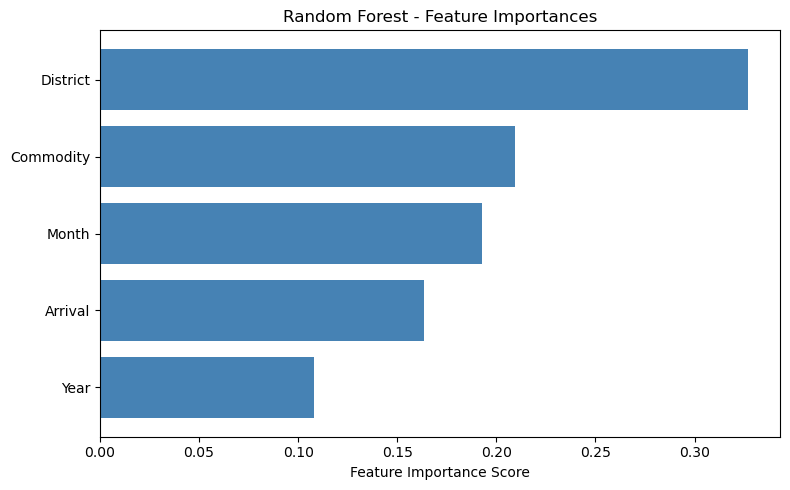

In [42]:


feature_names = X.columns
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), importances[indices], color='steelblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance Score')
plt.title('Random Forest - Feature Importances')
plt.tight_layout()
plt.savefig('../images/feature_importance.png')
plt.show()

In [43]:
Y_pred=model.predict(X_test)

## Results
The model was evaluated on the test set using:
- MAE (Mean Absolute Error) — measures average prediction error in Rs/quintal
- R2 Score — measures how well the model explains price variance

In [44]:
print("MAE:", mean_absolute_error(Y_test, Y_pred))
print("R2 Score:", r2_score(Y_test, Y_pred))

MAE: 1145.3828098869187
R2 Score: 0.8231128699449166


In [45]:
df['Predicted Price']=model.predict(X)

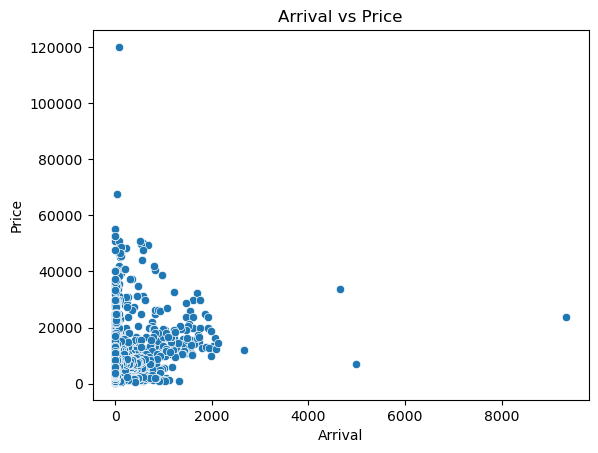

In [46]:
sns.scatterplot(x=df['Arrival'], y=df['Price'])
plt.title("Arrival vs Price")
plt.show()

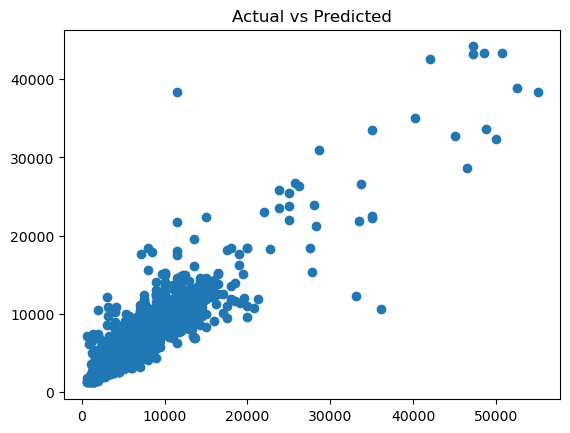

In [47]:
plt.scatter(Y_test, Y_pred)
plt.title("Actual vs Predicted")
plt.show()

In [48]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, Y, cv=5, scoring='r2')

print("CV Scores:", scores.round(3))
print("Mean R2:", round(scores.mean(), 3))
print("Std Dev:", round(scores.std(), 3))

CV Scores: [ 0.149 -0.129  0.117 -0.429 -0.184]
Mean R2: -0.095
Std Dev: 0.212


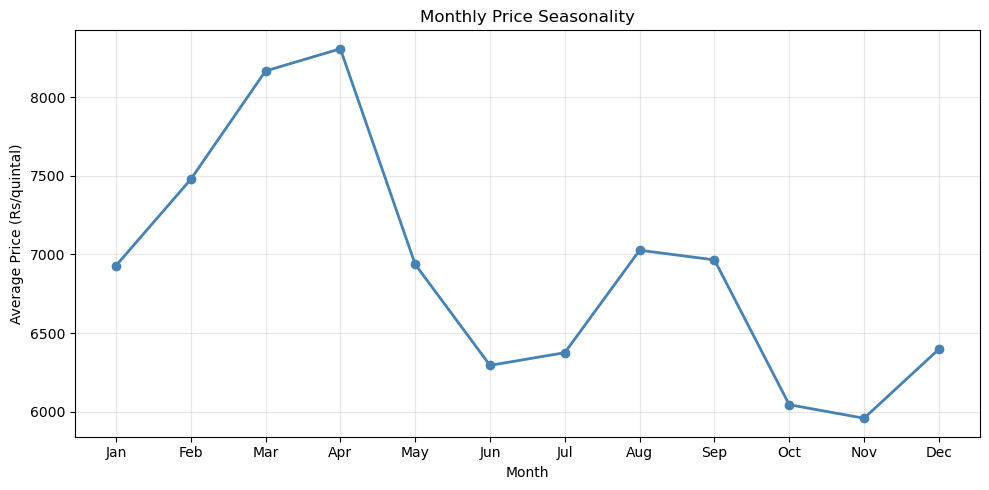

In [49]:
# Monthly Price Seasonality
df['Month'] = pd.to_datetime(df['Date']).dt.month
monthly_avg = df.groupby('Month')['Price'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly_avg['Month'], monthly_avg['Price'], 
         marker='o', color='steelblue', linewidth=2, markersize=6)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.xlabel('Month')
plt.ylabel('Average Price (Rs/quintal)')
plt.title('Monthly Price Seasonality')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/seasonality_chart.png')
plt.show()

In [50]:
# Separate models per commodity for better accuracy
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

print("=== Per-Commodity Model Performance ===\n")
models = {}

for commodity in df['Commodity'].unique():
    df_c = df[df['Commodity'] == commodity]
    X_c = df_c[['Arrival', 'Month', 'Year', 'District']]
    Y_c = df_c['Price']
    
    X_train_c, X_test_c, Y_train_c, Y_test_c = train_test_split(
        X_c, Y_c, test_size=0.2, random_state=42)
    
    model_c = RandomForestRegressor(
        n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
    model_c.fit(X_train_c, Y_train_c)
    
    Y_pred_c = model_c.predict(X_test_c)
    r2 = r2_score(Y_test_c, Y_pred_c)
    mae = mean_absolute_error(Y_test_c, Y_pred_c)
    
    print(f"{commodity}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  MAE: Rs. {mae:.2f}/quintal\n")
    
    models[commodity] = model_c

=== Per-Commodity Model Performance ===

1:
  R² Score: 0.8065
  MAE: Rs. 548.69/quintal

2:
  R² Score: 0.3449
  MAE: Rs. 1283.29/quintal

0:
  R² Score: 0.8664
  MAE: Rs. 1812.89/quintal



In [51]:
def predict_price_v2(arrival, month, year, commodity_name, district_name):
    commodity_map = {'Mango': 0, 'Orange': 1, 'Pomegranate': 2}
    
    if commodity_name not in commodity_map:
        print(f"Unknown commodity. Choose from: {list(commodity_map.keys())}")
        return None
    
    # Encode district using existing df
    district_codes = dict(zip(
        df['District'].astype('category').cat.categories,
        range(len(df['District'].astype('category').cat.categories))
    ))
    district_code = district_codes.get(district_name, 0)
    
    commodity_code = commodity_map[commodity_name]
    model_c = models[commodity_code]
    
    input_data = pd.DataFrame({
        'Arrival': [arrival],
        'Month': [month],
        'Year': [year],
        'District': [district_code]
    })
    
    predicted_price = model_c.predict(input_data)[0]
    return round(predicted_price, 2)

print("Updated Predictions:")
print(f"Pomegranate, Nashik, 50t, March 2026: Rs. {predict_price_v2(50, 3, 2026, 'Pomegranate', 'Nashik')}/quintal")
print(f"Orange, Pune, 100t, June 2026: Rs. {predict_price_v2(100, 6, 2026, 'Orange', 'Pune')}/quintal")
print(f"Mango, Amravati, 30t, April 2026: Rs. {predict_price_v2(30, 4, 2026, 'Mango', 'Amravati')}/quintal")

Updated Predictions:
Pomegranate, Nashik, 50t, March 2026: Rs. 7061.12/quintal
Orange, Pune, 100t, June 2026: Rs. 4121.67/quintal
Mango, Amravati, 30t, April 2026: Rs. 8038.93/quintal


In [52]:
# Separate models per commodity for better accuracy
import os
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Recover human-readable commodity names (Commodity column is label-encoded by this point)
commodity_names = {0: 'Mango', 1: 'Orange', 2: 'Pomegranate'}

os.makedirs('../models', exist_ok=True)

print("=== Per-Commodity Model Performance ===\n")
models = {}
results = {}

for commodity_code in sorted(df['Commodity'].unique()):
    commodity_name = commodity_names[commodity_code]
    df_c = df[df['Commodity'] == commodity_code]
    X_c = df_c[['Arrival', 'Month', 'Year', 'District']]
    Y_c = df_c['Price']

    X_train_c, X_test_c, Y_train_c, Y_test_c = train_test_split(
        X_c, Y_c, test_size=0.2, random_state=42)

    model_c = RandomForestRegressor(
        n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
    model_c.fit(X_train_c, Y_train_c)

    Y_pred_c = model_c.predict(X_test_c)
    r2 = r2_score(Y_test_c, Y_pred_c)
    mae = mean_absolute_error(Y_test_c, Y_pred_c)

    print(f"{commodity_name}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  MAE: Rs. {mae:.2f}/quintal\n")

    models[commodity_code] = model_c
    results[commodity_name] = {'r2': r2, 'mae': mae}

    # Save each model separately
    joblib.dump(model_c, f'../models/rf_model_{commodity_name.lower()}.pkl')

print(f"Saved {len(models)} models to ../models/")

=== Per-Commodity Model Performance ===

Mango:
  R² Score: 0.8664
  MAE: Rs. 1812.89/quintal

Orange:
  R² Score: 0.8065
  MAE: Rs. 548.69/quintal

Pomegranate:
  R² Score: 0.3449
  MAE: Rs. 1283.29/quintal

Saved 3 models to ../models/
